In [ ]:
pip install rasterio geopandas shapely pandas numpy --quiet

In [ ]:
import pandas as pd
import geopandas as gpd

# Buildings
buildings = pd.read_json("tokyo_buildings.json")

# Hospitals / firestations / landuse
hospitals = gpd.read_file("tokyo_hospitals.geojson")
firestations = gpd.read_file("tokyo_firestations.geojson")
landuse = gpd.read_file("tokyo_landuse.geojson")

In [ ]:
from shapely.geometry import Point

buildings["geometry"] = buildings.apply(
    lambda row: Point(row["lon"], row["lat"]), axis=1
)

buildings_gdf = gpd.GeoDataFrame(buildings, geometry="geometry", crs="EPSG:4326")

In [ ]:
import rasterio

raster = rasterio.open("landscan-mosaic-japan-v1.tif")

In [ ]:
import rasterio

pop_values = []
cell_ids = []

with rasterio.open("landscan-mosaic-japan-v1.tif") as src:
    for _, row in buildings_gdf.iterrows():
        lon, lat = row["lon"], row["lat"]

        # get raster cell index
        r, c = src.index(lon, lat)

        # sample population
        val = list(src.sample([(lon, lat)]))[0][0]

        pop_values.append(val)
        cell_ids.append((r, c))

# store both
buildings_gdf["cell_population"] = pop_values
buildings_gdf["cell_id"] = cell_ids

# ✅ CORRECT GROUPING
buildings_gdf["building_count_in_cell"] = (
    buildings_gdf.groupby("cell_id")["cell_id"]
    .transform("count")
)

In [ ]:
weights = {
    "residential": 1,
    "apartments": 6,
    "commercial": 3,
    "office": 8,
    "school": 15,
    "hospital": 20,
    "industrial": 2,
    "warehouse": 1
}

def get_weight(row):
    return weights.get(row.get("type", "residential"), 1)

buildings_gdf["weight"] = buildings_gdf.apply(get_weight, axis=1)

# compute total weight per cell
buildings_gdf["total_weight_in_cell"] = (
    buildings_gdf.groupby("cell_id")["weight"]
    .transform("sum")
)

# compute population correctly
buildings_gdf["population"] = (
    buildings_gdf["cell_population"] *
    (buildings_gdf["weight"] / buildings_gdf["total_weight_in_cell"])
)

In [ ]:
# -------------------------
# NORMALIZATION STEP
# -------------------------

total_building_pop = buildings_gdf["population"].sum()
total_raster_pop = buildings_gdf["cell_population"].sum()

scale_factor = total_raster_pop / total_building_pop

buildings_gdf["population"] = buildings_gdf["population"] * scale_factor

print("After normalization:")
print("Building pop:", buildings_gdf["population"].sum())
print("Raster pop:", buildings_gdf["cell_population"].sum())

After normalization:
Building pop: 1205971.375
Raster pop: 1205971.4


In [ ]:
print(landuse.columns)

Index(['element', 'id', 'landuse', 'geometry'], dtype='object')


In [ ]:
# -------------------------
# LANDUSE JOIN
# -------------------------

# make sure CRS matches
landuse = landuse.to_crs(buildings_gdf.crs)

# spatial join (attach landuse to each building)
buildings_gdf = gpd.sjoin(
    buildings_gdf,
    landuse[["landuse", "geometry"]],
    how="left",
    predicate="within"
)

# -------------------------
# LANDUSE MULTIPLIER
# -------------------------

def landuse_multiplier(lu):
    if lu == "residential":
        return 1.2
    elif lu == "commercial":
        return 1.0
    elif lu == "industrial":
        return 0.6
    elif lu == "retail":
        return 1.1
    elif lu == "construction":
        return 0.3
    elif lu == "grass":
        return 0.2
    elif lu == "forest":
        return 0.1
    else:
        return 1.0  # default

# apply safely
buildings_gdf["lu_weight"] = buildings_gdf["landuse"].apply(
    lambda x: landuse_multiplier(x) if pd.notnull(x) else 1.0
)

# apply adjustment
buildings_gdf["population"] = (
    buildings_gdf["population"] * buildings_gdf["lu_weight"]
)

In [ ]:
# -------------------------
# RE-NORMALIZE
# -------------------------

total_building_pop = buildings_gdf["population"].sum()
total_raster_pop = buildings_gdf["cell_population"].sum()

scale_factor = total_raster_pop / total_building_pop

buildings_gdf["population"] = buildings_gdf["population"] * scale_factor

print("After landuse normalization:")
print("Building pop:", buildings_gdf["population"].sum())
print("Raster pop:", buildings_gdf["cell_population"].sum())

After landuse normalization:
Building pop: 1205971.375
Raster pop: 1205971.4


In [ ]:
buildings_gdf["landuse"].value_counts().head(10)

,count
landuse,
地域熱供給,26
forest,7
commercial,5
proposed,5
retail,4
harbour,3
residential,2
railway,1
construction,1


In [ ]:
buildings_gdf["population"] = buildings_gdf["population"].fillna(0)
buildings_gdf["population"] = buildings_gdf["population"].round().astype(int)

In [ ]:
building_nodes = []

for _, row in buildings_gdf.iterrows():
    building_nodes.append({
        "id": int(row["id"]),
        "lat": float(row["lat"]),
        "lon": float(row["lon"]),
        "type": "building",
        "population": int(row["population"])
    })

In [ ]:
import os
print(os.listdir())

['.config', 'tokyo_landuse.geojson', 'tokyo_firestations.geojson', 'landscan-mosaic-japan-v1.tif', 'tokyo_bridges.geojson', 'tokyo_hospitals.geojson', 'tokyo_roads.zip', 'tokyo_rivers.geojson', 'tokyo_buildings.json', 'sample_data']


In [ ]:
import zipfile

zip_path = "tokyo_roads.zip"  # change if needed

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()  # extracts to current directory

import json

with open("tokyo_roads.json", "r") as f:
    data = f.read()

# remove any junk before first {
start = data.find("{")
data = data[start:]

graph = json.loads(data)

graph["nodes"].extend(building_nodes)

with open("tokyo_full_graph.json", "w") as f:
    json.dump(graph, f, indent=2)

In [ ]:
with open("tokyo_roads.json") as f:
    print(repr(f.read()[:100]))

'W{\n  "city": "Tokyo",\n  "nodes": [\n    {\n      "id": 31236584,\n      "lat": 35.6349354,\n      "lon":'


CHECK

In [ ]:
print(buildings_gdf["population"].sum())
print(buildings_gdf["cell_population"].sum())

1205997
1205971.4


In [ ]:
buildings_gdf["population"].describe()

,population
count,10000.00000
mean,120.59970
std,130.95842
min,0.00000
25%,35.00000
50%,83.00000
75%,156.00000
max,1309.00000


<Axes: >

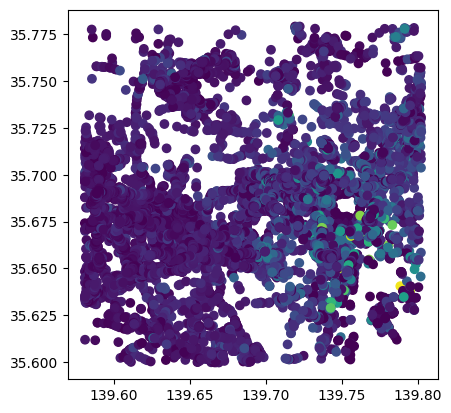

In [ ]:
buildings_gdf.plot(column="population")

In [ ]:
buildings_gdf.groupby("type")["population"].mean()

,population
type,
apartments,130.618999
commercial,123.243323
government,100.949537
hospital,150.162512
industrial,114.597889
office,133.823177
residential,100.077756
retail,115.010690
school,141.238743
